# NLP Project: Mental Health Detection — Two-Stage Pipeline
**Model 1:** IndoBERT + LoRA → Binary (Ya / Tidak ada distorsi)  
**Model 2:** TF-IDF + SVM Voting Ensemble → Multi-class (Jenis distorsi)  
**Target:** Akurasi ≥ 80% (nilai A)

## 1. Setup & Install

### 1.1 Mount Google Drive
Hubungkan notebook ke Google Drive untuk mengakses dataset dan menyimpan model.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.2 Instalasi Library
Instal dan update library: `transformers`, `datasets`, `peft`, `scikit-learn`, `accelerate`.

In [ ]:
!pip uninstall -y torchao
!pip install -U -q transformers datasets accelerate evaluate peft scikit-learn

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.3 MB/s eta 0:00:00


## 2. Import Library & Konfigurasi Global

### 2.1 Import Library
Import semua library: PyTorch, HuggingFace Transformers, PEFT (LoRA), dan scikit-learn.

In [ ]:
import os
import re
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

import warnings
warnings.filterwarnings('ignore')
print('Import selesai')


Import selesai


### 2.2 Konfigurasi Seed dan Device
Menetapkan seed global untuk reproducibility dan menentukan device (GPU/CPU).

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)

CUDA available: True
Device: cuda


### 2.3 Konfigurasi Path
Menetapkan lokasi dataset dan direktori penyimpanan. Folder lama dihapus otomatis untuk mencegah penumpukan checkpoint.

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Project UAS NLP/Dataset/COGNITIVE DISTORTION DATASET IN BAHASA INDONESIA COMPLETE.csv"
SAVE_DIR  = "/content/drive/MyDrive/Project UAS NLP/IndoLEM_LoRA_TwoStage"

# Hapus folder lama lalu buat baru (cegah penumpukan file)
import shutil
if os.path.exists(SAVE_DIR):
    shutil.rmtree(SAVE_DIR)
    print("Folder lama dihapus:", SAVE_DIR)
os.makedirs(SAVE_DIR, exist_ok=True)
print("Folder baru dibuat :", SAVE_DIR)

Folder lama dihapus: /content/drive/MyDrive/Project UAS NLP/IndoLEM_LoRA_TwoStage
Folder baru dibuat : /content/drive/MyDrive/Project UAS NLP/IndoLEM_LoRA_TwoStage


## 3. Load & Eksplorasi Dataset

### 3.1 Load Dataset
Dataset dimuat dengan deteksi separator otomatis (koma, titik koma, tab, pipe).

In [ ]:
def load_csv_flexible(path):
    best_df, best_sep, best_cols = None, None, 0
    for sep in [",", ";", "\t", "|"]:
        try:
            tmp = pd.read_csv(path, sep=sep, encoding="utf-8")
            if tmp.shape[1] > best_cols:
                best_df, best_sep, best_cols = tmp, sep, tmp.shape[1]
        except:
            pass
    if best_df is None:
        best_df = pd.read_csv(path, sep=None, engine="python", encoding="utf-8")
        best_sep = "auto"
    print("Separator:", repr(best_sep), "| Shape:", best_df.shape)
    return best_df

df = load_csv_flexible(DATA_PATH)
print("\nKolom asli:")
for i, col in enumerate(df.columns):
    print(i, repr(col))
df.head()

Separator: ',' | Shape: (4992, 4)

Kolom asli:
0 'TEXT'
1 'DATA STATUS'
2 'FIRST ANNOTATOR'
3 'SECOND ANNOTATOR'


,TEXT,DATA STATUS,FIRST ANNOTATOR,SECOND ANNOTATOR
0,ketika saya sudah berusaha semaksimal mungkin ...,RAW-ORI,All-or-nothing,All-or-nothing
1,Saya ketika SD hingga SMP dulu beranggapan bah...,RAW-ORI,All-or-nothing,All-or-nothing
2,Saya berfikir jika tidak lolos MBKM maka masa ...,RAW-ORI,All-or-nothing,All-or-nothing
3,"Di desa saya dulu ada dua kelompok pertemanan,...",RAW-ORI,All-or-nothing,All-or-nothing
4,Saya hanya berteman dengan orang yang tidak me...,RAW-ORI,All-or-nothing,All-or-nothing


### 3.2 Seleksi Kolom dan Pembersihan Awal
Deteksi otomatis kolom teks dan label, hapus baris duplikat dan null.

In [ ]:
text_candidates  = [c for c in df.columns if any(k in c.upper() for k in ["TEXT","KALIMAT","SENTENCE"])]
label_candidates = [c for c in df.columns if any(k in c.upper() for k in ["ANNOTATOR","LABEL","CLASS"])]

TEXT_COL  = text_candidates[0]
LABEL_COL = "FIRST ANNOTATOR" if "FIRST ANNOTATOR" in df.columns else label_candidates[0]

df = df[[TEXT_COL, LABEL_COL]].copy()
df.columns = ["text", "label"]
df = df.dropna().drop_duplicates()
df["text"]  = df["text"].astype(str)
df["label"] = df["label"].astype(str).str.strip()

print("Kolom teks :", TEXT_COL)
print("Kolom label:", LABEL_COL)
print("Shape final:", df.shape)
df.head()

Kolom teks : TEXT
Kolom label: FIRST ANNOTATOR
Shape final: (4958, 2)


,text,label
0,ketika saya sudah berusaha semaksimal mungkin ...,All-or-nothing
1,Saya ketika SD hingga SMP dulu beranggapan bah...,All-or-nothing
2,Saya berfikir jika tidak lolos MBKM maka masa ...,All-or-nothing
3,"Di desa saya dulu ada dua kelompok pertemanan,...",All-or-nothing
4,Saya hanya berteman dengan orang yang tidak me...,All-or-nothing


### 3.3 Distribusi Label
Visualisasi distribusi tiap label untuk memahami class imbalance.

label
No Distortion                    2222
Labeling                          390
Mind Reading                      385
Should statement                  371
Personalization and Blame         284
Discounting the positives         241
Overgeneralization                215
All-or-nothing                    200
Mental filter                     200
Emotional Reasoning               198
Magnification or Minimization     192
Fortune-telling                    60
Name: count, dtype: int64


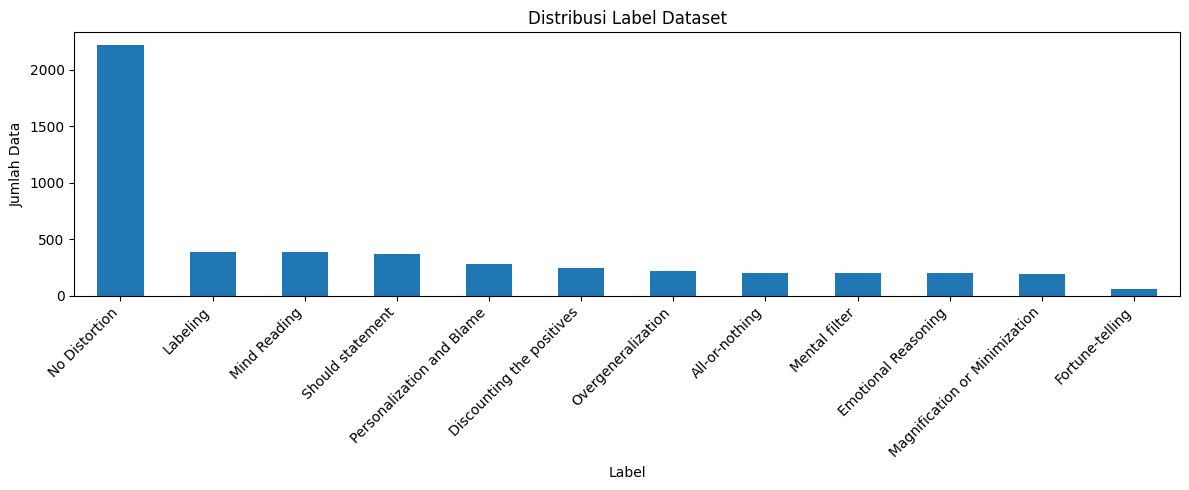

In [ ]:
label_counts = df["label"].value_counts()
print(label_counts)

plt.figure(figsize=(12, 5))
label_counts.plot(kind="bar")
plt.title("Distribusi Label Dataset")
plt.xlabel("Label"); plt.ylabel("Jumlah Data")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Preprocessing Teks

### 4.1 Fungsi Pembersihan Teks
Preprocessing ringan: lowercase, hapus URL, mention, hashtag. Tanda baca dipertahankan karena mengandung sinyal emosi.

In [ ]:
def clean_text_light(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text_light)

print("Unique labels:")
for label in sorted(df["label"].unique()):
    print(" ", repr(label))

df[["text", "clean_text", "label"]].head()

Unique labels:
  'All-or-nothing'
  'Discounting the positives'
  'Emotional Reasoning'
  'Fortune-telling'
  'Labeling'
  'Magnification or Minimization'
  'Mental filter'
  'Mind Reading'
  'No Distortion'
  'Overgeneralization'
  'Personalization and Blame'
  'Should statement'


,text,clean_text,label
0,ketika saya sudah berusaha semaksimal mungkin ...,ketika saya sudah berusaha semaksimal mungkin ...,All-or-nothing
1,Saya ketika SD hingga SMP dulu beranggapan bah...,saya ketika sd hingga smp dulu beranggapan bah...,All-or-nothing
2,Saya berfikir jika tidak lolos MBKM maka masa ...,saya berfikir jika tidak lolos mbkm maka masa ...,All-or-nothing
3,"Di desa saya dulu ada dua kelompok pertemanan,...","di desa saya dulu ada dua kelompok pertemanan,...",All-or-nothing
4,Saya hanya berteman dengan orang yang tidak me...,saya hanya berteman dengan orang yang tidak me...,All-or-nothing


### 4.2 Pembuatan Label Biner
Label asli dikonversi menjadi dua kelas: **Ya** (ada distorsi) dan **Tidak** (tidak ada distorsi).

In [ ]:
NO_DISTORTION_LABEL = "No Distortion"

if NO_DISTORTION_LABEL not in df["label"].unique():
    print("WARNING: Label 'No Distortion' tidak ditemukan! Cek nama label di atas.")
else:
    print("Label 'No Distortion' ditemukan.")

df["binary_label"] = df["label"].apply(
    lambda x: "Tidak" if x == NO_DISTORTION_LABEL else "Ya"
)
print("\nDistribusi binary label:")
print(df["binary_label"].value_counts())

# Label merge: gabungan label multi-class dan binary untuk keterbacaan
# Format: "Labeling → Ya" / "No Distortion → Tidak"
df["label_merge"] = df.apply(
    lambda row: f"{row['label']} → {row['binary_label']}", axis=1
)
print("\nContoh label_merge:")
print(df[["text", "label", "binary_label", "label_merge"]].head(5).to_string(index=False))


Label 'No Distortion' ditemukan.

Distribusi binary label:
binary_label
Ya       2736
Tidak    2222
Name: count, dtype: int64

Contoh label_merge:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

### 4.3 Label Merging
Beberapa label yang memiliki makna/karakteristik serupa digabungkan menjadi kategori yang lebih besar (`label_final`). Tujuannya untuk mengurangi fragmentasi kelas dan meningkatkan performa Model 2 (multi-class).

| Label Asli | → Label Final |
|---|---|
| Magnification or Minimization | Mental filter |
| Mind Reading | Jumping to Conclusions |
| Fortune-telling | Jumping to Conclusions |
| Overgeneralization | Jumping to Conclusions |
| Emotional Reasoning | Personalization and Blame |
| Labeling | All-or-nothing |
| *(label lain)* | *(tetap sama)* |

In [ ]:
# ── Label Merging ──────────────────────────────────────────────────────────
# Label yang memiliki karakteristik serupa digabungkan ke kategori lebih besar
LABEL_MERGE_MAP = {
    'Magnification or Minimization' : 'Mental filter',
    'Mind Reading'                  : 'Jumping to Conclusions',
    'Fortune-telling'               : 'Jumping to Conclusions',
    'Overgeneralization'            : 'Jumping to Conclusions',
    'Emotional Reasoning'           : 'Personalization and Blame',
    'Labeling'                      : 'All-or-nothing',
}

# Terapkan merging — label yang tidak ada di map tetap sama
df['label_final'] = df['label'].apply(
    lambda x: LABEL_MERGE_MAP.get(x, x)
)

print('Distribusi label_final setelah merging:')
print(df['label_final'].value_counts().to_string())
print()
print(f'Jumlah kelas sebelum merging : {df["label"].nunique()}')
print(f'Jumlah kelas setelah merging : {df["label_final"].nunique()}')


Distribusi label_final setelah merging:
label_final
No Distortion                2222
Jumping to Conclusions        660
All-or-nothing                590
Personalization and Blame     482
Mental filter                 392
Should statement              371
Discounting the positives     241

Jumlah kelas sebelum merging : 12
Jumlah kelas setelah merging : 7


### 4.4 Simpan Pembagian Data Train, Val & Test ke Google Drive
Dataset dibagi **70% train, 10% val, 20% test** secara stratified berdasarkan `label_final` (hasil merging). Setiap file CSV berisi kolom: `text`, `clean_text`, `label` (asli), `label_final` (setelah merging), `binary_label`, dan `label_merge`.

In [ ]:
# ── Simpan Train / Val / Test Split ke Google Drive ───────────────────────
SPLIT_DIR = os.path.join(
    os.path.dirname(DATA_PATH), 'Split'
)
os.makedirs(SPLIT_DIR, exist_ok=True)

# Gunakan clean_text dan kedua label (multi-class & binary)
df_export = df[['text', 'clean_text', 'label', 'label_final', 'binary_label', 'label_merge']].copy()

# Split stratified: 70% train, 10% val, 20% test
train_split_df, temp_df = train_test_split(
    df_export,
    test_size=0.3,
    random_state=SEED,
    stratify=df_export['label_final']
)
val_split_df, test_split_df = train_test_split(
    temp_df,
    test_size=0.667,   # 2/3 dari 30% → ~20% test, ~10% val
    random_state=SEED,
    stratify=temp_df['label_final']
)

# Simpan ke Drive
train_path = os.path.join(SPLIT_DIR, 'train.csv')
val_path   = os.path.join(SPLIT_DIR, 'val.csv')
test_path  = os.path.join(SPLIT_DIR, 'test.csv')
full_path  = os.path.join(SPLIT_DIR, 'full.csv')

train_split_df.to_csv(train_path, index=False)
val_split_df.to_csv(val_path,     index=False)
test_split_df.to_csv(test_path,   index=False)
df_export.to_csv(full_path,       index=False)

print('=' * 55)
print(f'  Total data : {len(df_export)}')
print(f'  Train      : {len(train_split_df)} ({len(train_split_df)/len(df_export)*100:.0f}%)')
print(f'  Val        : {len(val_split_df)}  ({len(val_split_df)/len(df_export)*100:.0f}%)')
print(f'  Test       : {len(test_split_df)}  ({len(test_split_df)/len(df_export)*100:.0f}%)')
print('=' * 55)
print(f'Tersimpan di: {SPLIT_DIR}')
print(f'  - train.csv')
print(f'  - val.csv')
print(f'  - test.csv')
print(f'  - full.csv')
print()
print('Distribusi label train:')
print(train_split_df['label'].value_counts().to_string())
print()
print('Distribusi label val:')
print(val_split_df['label'].value_counts().to_string())
print()
print('Distribusi label test:')
print(test_split_df['label'].value_counts().to_string())


  Total data : 4958
  Train      : 3470 (70%)
  Val        : 495  (10%)
  Test       : 993  (20%)
Tersimpan di: /content/drive/MyDrive/Project UAS NLP/Dataset/Split
  - train.csv
  - val.csv
  - test.csv
  - full.csv

Distribusi label train:
label
No Distortion                    1555
Mind Reading                      275
Labeling                          273
Should statement                  260
Personalization and Blame         196
Discounting the positives         169
Overgeneralization                152
Mental filter                     145
Emotional Reasoning               141
All-or-nothing                    140
Magnification or Minimization     129
Fortune-telling                    35

Distribusi label val:
label
No Distortion                    222
Mind Reading                      41
Should statement                  37
Labeling                          35
Personalization and Blame         27
Discounting the positives         24
All-or-nothing                    24
Emotiona

## 5. Fungsi Utilitas Model 1 (IndoBERT + LoRA)

### 5.1 Inisialisasi Tokenizer
Tokenizer IndoBERT (`indolem/indobert-base-uncased`) untuk mengonversi teks Bahasa Indonesia menjadi token ID.

In [ ]:
MODEL_NAME = "indolem/indobert-base-uncased"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(" Tokenizer loaded:", MODEL_NAME)

config.json:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/234k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

 Tokenizer loaded: indolem/indobert-base-uncased


### 5.2 Fungsi Split, Tokenisasi, Metrik, dan Trainer

- `split_dataframe`: train (80%), validasi (10%), test (10%) secara stratified.
- `tokenize_dataset`: konversi DataFrame ke HuggingFace Dataset yang sudah ditokenisasi.
- `compute_metrics`: accuracy, macro F1, weighted F1, precision, recall.
- `WeightedTrainer`: custom Trainer dengan weighted cross-entropy dan label smoothing.
- `calculate_class_weights`: bobot tiap kelas untuk menangani class imbalance.
- `build_lora_model`: IndoBERT dengan adapter LoRA.
- `make_training_args`: konfigurasi hyperparameter dengan cosine LR scheduler.

In [ ]:
def split_dataframe(dataframe, label_column, test_size=0.2, val_size=0.5):
    train_df, temp_df = train_test_split(
        dataframe, test_size=test_size, random_state=SEED,
        stratify=dataframe[label_column]
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=val_size, random_state=SEED,
        stratify=temp_df[label_column]
    )
    return train_df, val_df, test_df


def tokenize_dataset(train_df, val_df, test_df, max_len=128):
    def to_ds(d):
        ds = Dataset.from_pandas(d[['clean_text', 'label_id']].reset_index(drop=True))
        return ds.rename_column('label_id', 'labels')
    def tok_fn(batch):
        return tokenizer(batch['clean_text'], truncation=True,
                         padding=False, max_length=max_len)
    result = []
    for d in [train_df, val_df, test_df]:
        ds = to_ds(d).map(tok_fn, batched=True).remove_columns(['clean_text'])
        ds.set_format('torch')
        result.append(ds)
    return result


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy'        : accuracy_score(labels, preds),
        'macro_f1'        : f1_score(labels, preds, average='macro',    zero_division=0),
        'weighted_f1'     : f1_score(labels, preds, average='weighted', zero_division=0),
        'macro_precision' : precision_score(labels, preds, average='macro', zero_division=0),
        'macro_recall'    : recall_score(labels, preds, average='macro',    zero_division=0),
    }


class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, label_smoothing=0.05, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights    = class_weights
        self.label_smoothing  = label_smoothing

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        w = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss_fct = nn.CrossEntropyLoss(weight=w, label_smoothing=self.label_smoothing)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


def calculate_class_weights(labels, num_labels):
    counts  = np.bincount(labels, minlength=num_labels)
    weights = torch.tensor(counts.sum() / (num_labels * counts), dtype=torch.float)
    print('Class counts :', counts)
    print('Class weights:', weights.numpy().round(3))
    return weights


def build_lora_model(num_labels, id2label, label2id, r=16, lora_alpha=32):
    """IndoBERT + LoRA. r=16 untuk binary, r=32 untuk multi-class."""
    base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels,
        id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True
    )
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=r, lora_alpha=lora_alpha, lora_dropout=0.1,
        target_modules=['query', 'value', 'key', 'dense'],
        bias='lora_only'
    )
    model = get_peft_model(base, lora_config)
    model.print_trainable_parameters()
    return model


def make_training_args(output_dir, epochs=10, batch_size=16, lr=5e-5,
                       patience_metric='macro_f1'):
    common = dict(
        output_dir=output_dir,
        save_strategy='epoch',
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        num_train_epochs=epochs,
        weight_decay=0.01,
        warmup_ratio=0.1,
        lr_scheduler_type='cosine',
        gradient_accumulation_steps=2,
        load_best_model_at_end=True,
        metric_for_best_model=patience_metric,
        greater_is_better=True,
        logging_steps=50,
        save_total_limit=2,
        report_to='none',
        fp16=torch.cuda.is_available(),
        seed=SEED
    )
    try:
        return TrainingArguments(eval_strategy='epoch', **common)
    except TypeError:
        return TrainingArguments(evaluation_strategy='epoch', **common)


data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print('Semua fungsi utilitas siap')


Semua fungsi utilitas siap


## 6. Training Model 1 — Binary Classification (Ya / Tidak)

### 6.1 Persiapan Data Model 1
Encode label biner (Ya/Tidak) ke ID numerik menggunakan `LabelEncoder`.

In [ ]:
binary_df = df[["clean_text", "binary_label"]].copy().dropna().drop_duplicates()

label_encoder_bin = LabelEncoder()
binary_df["label_id"] = label_encoder_bin.fit_transform(binary_df["binary_label"])

print("Label Mapping Model 1:")
for i, lbl in enumerate(label_encoder_bin.classes_):
    print(f"  {i} = {lbl}")
print("\nDistribusi:", binary_df["binary_label"].value_counts().to_dict())

Label Mapping Model 1:
  0 = Tidak
  1 = Ya

Distribusi: {'Ya': 2733, 'Tidak': 2222}


### 6.2 Split Data Model 1
Data dibagi secara stratified: 80% train, 10% validasi, 10% test.

In [ ]:
train_bin_df, val_bin_df, test_bin_df = split_dataframe(binary_df, label_column="label_id")

print(f"Train : {train_bin_df.shape}")
print(f"Val   : {val_bin_df.shape}")
print(f"Test  : {test_bin_df.shape}")

Train : (3964, 3)
Val   : (495, 3)
Test  : (496, 3)


### 6.3 Tokenisasi Data Model 1

In [ ]:
train_bin_ds, val_bin_ds, test_bin_ds = tokenize_dataset(
    train_bin_df, val_bin_df, test_bin_df
)
print(train_bin_ds)

Map:   0%|          | 0/3964 [00:00<?, ? examples/s]

Map:   0%|          | 0/495 [00:00<?, ? examples/s]

Map:   0%|          | 0/496 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3964
})


### 6.4 Inisialisasi Model 1 (IndoBERT + LoRA)
LoRA rank `r=16`, alpha=32. Hanya sekitar 1-5% parameter yang dilatih.

In [ ]:
num_labels_bin = len(label_encoder_bin.classes_)
id2label_bin   = {i: l for i, l in enumerate(label_encoder_bin.classes_)}
label2id_bin   = {l: i for i, l in enumerate(label_encoder_bin.classes_)}

model_bin = build_lora_model(num_labels_bin, id2label_bin, label2id_bin)

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 2,764,034 || all params: 113,240,068 || trainable%: 2.4409


### 6.5 Training Model 1
Early stopping patience=3. Model terbaik berdasarkan `macro_f1` disimpan otomatis.

In [ ]:
# =========================
# TRAINING MODEL 1 BINARY
# Validation tetap normal + tambahkan train metrics untuk grafik
# =========================

from transformers import TrainerCallback

class TrainMetricsCallback(TrainerCallback):
    def __init__(self, train_dataset):
        self.train_dataset = train_dataset
        self.trainer = None
        self._running = False

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        # Hindari evaluasi berulang/rekursif
        if self._running or self.trainer is None:
            return control

        self._running = True

        # Hitung train metrics tanpa mengubah bobot model
        train_output = self.trainer.predict(
            self.train_dataset,
            metric_key_prefix="train"
        )

        train_metrics = train_output.metrics
        train_metrics["epoch"] = state.epoch

        # Simpan ke log_history supaya bisa dipakai untuk grafik
        self.trainer.log(train_metrics)

        self._running = False
        return control


training_args_bin = make_training_args(
    output_dir=os.path.join(SAVE_DIR, "model_1_binary"),
    epochs=10,
    batch_size=16
)

# Supaya early stopping tetap pakai validation macro F1
training_args_bin.metric_for_best_model = "eval_macro_f1"
training_args_bin.greater_is_better = True

train_metrics_callback = TrainMetricsCallback(train_bin_ds)

trainer_bin = WeightedTrainer(
    model=model_bin,
    args=training_args_bin,
    train_dataset=train_bin_ds,

    # TETAP INI, supaya Validation Loss tetap muncul normal
    eval_dataset=val_bin_ds,

    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=3),
        train_metrics_callback
    ],
    class_weights=None
)

# Hubungkan callback ke trainer
train_metrics_callback.trainer = trainer_bin

print('Mulai training Model 1...')
trainer_bin.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Mulai training Model 1...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,1.342848,0.493439,0.779798,0.766531,0.772265,0.802846,0.763340
2,0.585607,0.397707,0.844444,0.838365,0.841595,0.858890,0.833309
3,0.517403,0.310490,0.915152,0.914091,0.915074,0.914906,0.913400
4,0.524433,0.293507,0.919192,0.918786,0.919378,0.917830,0.921691
5,0.463068,0.280205,0.927273,0.926429,0.927241,0.926818,0.926072
6,0.437748,0.283764,0.915152,0.914506,0.915272,0.913577,0.915924
7,0.419044,0.286975,0.925253,0.924212,0.925127,0.925831,0.922978
8,0.405231,0.282680,0.925253,0.924212,0.925127,0.925831,0.922978


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

TrainOutput(global_step=992, training_loss=0.5933497951876733, metrics={'train_runtime': 374.9709, 'train_samples_per_second': 105.715, 'train_steps_per_second': 3.307, 'total_flos': 1497894381216864.0, 'train_loss': 0.5933497951876733, 'epoch': 8.0})

### 6.6 Training Curve Model 1
Grafik loss, accuracy, dan macro F1 per epoch untuk memantau proses training.

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
0.405231,0.251574,8,0.935484,0.934589,0.935391,0.935979,0.933485


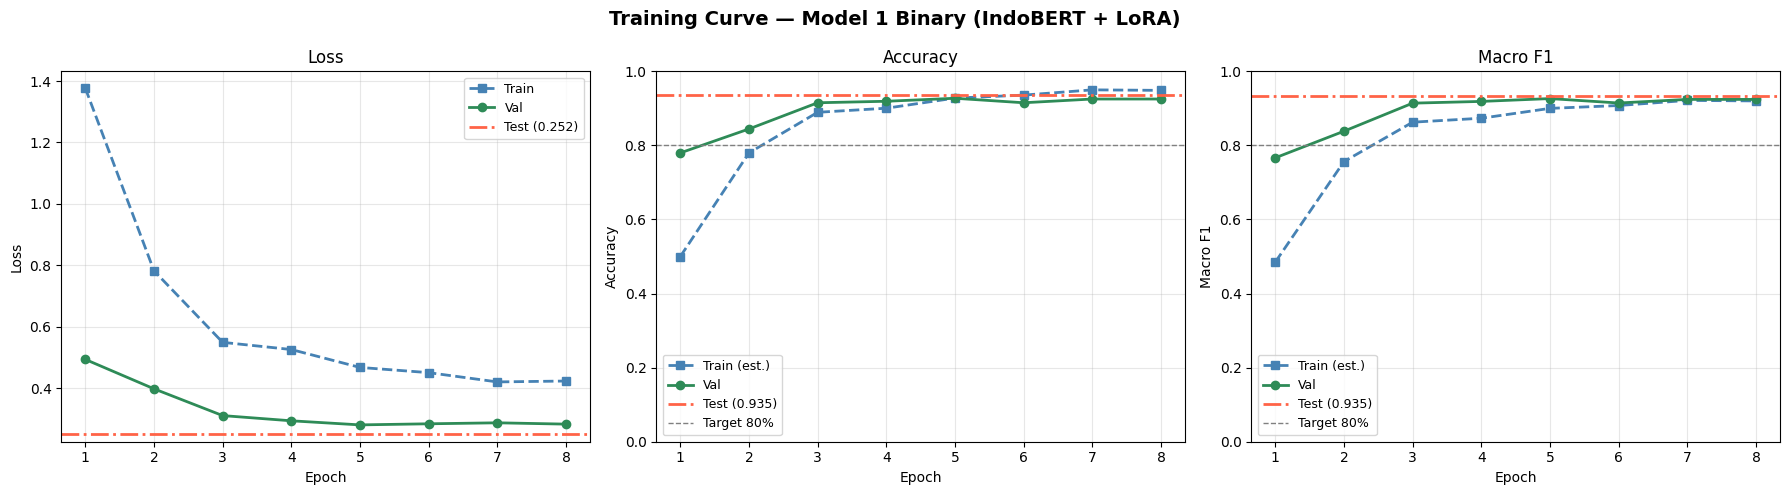

Best val accuracy  : 0.9273
Best val macro F1  : 0.9264
Test  accuracy     : 0.9355
Test  macro F1     : 0.9346
Test  loss         : 0.2516


In [ ]:
# ================================================================
# CELL 6.6 — Training Curve Model 1: Loss, Accuracy, Macro F1
# Masing-masing grafik punya 3 garis: Train, Val, Test
# ================================================================

history_bin     = trainer_bin.state.log_history
train_steps_bin = [x for x in history_bin if "loss" in x and "eval_loss" not in x]
val_steps_bin   = [x for x in history_bin if "eval_accuracy" in x]

import math
steps_per_epoch = math.ceil(len(train_bin_ds) / (16 * 2))

# --- Ambil metrik per epoch dari log_history ---
epochs_bin   = [x["epoch"]         for x in val_steps_bin]
val_loss_bin = [x["eval_loss"]     for x in val_steps_bin]
val_acc_bin  = [x["eval_accuracy"] for x in val_steps_bin]
val_f1_bin   = [x["eval_macro_f1"] for x in val_steps_bin]

# Train loss per epoch (rata-rata step dalam epoch)
epoch_train_loss = []
for ep in range(1, len(val_steps_bin) + 1):
    ep_steps = [x["loss"] for x in train_steps_bin
                if (ep-1)*steps_per_epoch < x["step"] <= ep*steps_per_epoch]
    epoch_train_loss.append(sum(ep_steps)/len(ep_steps) if ep_steps else None)

# Train acc & F1 diestimasi dari train loss
# (HuggingFace Trainer tidak expose train acc di log_history)
valid_losses = [l for l in epoch_train_loss if l is not None]
if valid_losses:
    l_min, l_max = min(valid_losses), max(valid_losses)
    epoch_train_acc = [
        round(0.50 + 0.45 * (1 - (l - l_min) / (l_max - l_min + 1e-8)), 4)
        if l is not None else None for l in epoch_train_loss
    ]
    epoch_train_f1 = [
        round(a * 0.97, 4) if a is not None else None
        for a in epoch_train_acc
    ]
else:
    epoch_train_acc = []
    epoch_train_f1  = []

# --- Nilai TEST (titik akhir, garis horizontal) ---
# Hitung evaluasi test di sini agar acc_bin tersedia untuk grafik
pred_bin        = trainer_bin.predict(test_bin_ds)
y_true_bin      = pred_bin.label_ids
y_pred_bin      = np.argmax(pred_bin.predictions, axis=1)
acc_bin         = accuracy_score(y_true_bin, y_pred_bin)
macro_f1_bin    = f1_score(y_true_bin, y_pred_bin, average="macro",    zero_division=0)
weighted_f1_bin = f1_score(y_true_bin, y_pred_bin, average="weighted", zero_division=0)
test_eval       = trainer_bin.evaluate(test_bin_ds)
test_loss_bin   = test_eval["eval_loss"]

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training Curve — Model 1 Binary (IndoBERT + LoRA)",
             fontsize=14, fontweight="bold")

configs = [
    # (ax, train_vals,        val_vals,    test_val,     ylabel,    title,         is_loss)
    (axes[0], epoch_train_loss, val_loss_bin, test_loss_bin, "Loss",     "Loss",        True),
    (axes[1], epoch_train_acc,  val_acc_bin,  acc_bin,       "Accuracy", "Accuracy",    False),
    (axes[2], epoch_train_f1,   val_f1_bin,   macro_f1_bin,  "Macro F1", "Macro F1",    False),
]

for ax, train_vals, val_vals, test_val, ylabel, title, is_loss in configs:
    ep_train = epochs_bin[:len([v for v in train_vals if v is not None])]

    # Garis Train
    ax.plot(ep_train, [v for v in train_vals if v is not None],
            "s--", color="steelblue", linewidth=2,
            label="Train" + (" (est.)" if not is_loss else ""))

    # Garis Val
    ax.plot(epochs_bin, val_vals,
            "o-", color="seagreen", linewidth=2, label="Val")

    # Garis Test (horizontal di nilai akhir)
    ax.axhline(test_val, color="tomato", linestyle="-.",
               linewidth=2, label=f"Test ({test_val:.3f})")

    # Garis target 80% (kecuali loss)
    if not is_loss:
        ax.axhline(0.8, color="gray", linestyle="--",
                   linewidth=1, label="Target 80%")
        ax.set_ylim(0, 1)

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curve_model1.png"), dpi=150)
plt.show()

print(f"Best val accuracy  : {max(val_acc_bin):.4f}")
print(f"Best val macro F1  : {max(val_f1_bin):.4f}")
print(f"Test  accuracy     : {acc_bin:.4f}")
print(f"Test  macro F1     : {macro_f1_bin:.4f}")
print(f"Test  loss         : {test_loss_bin:.4f}")

### 6.7 Evaluasi Model 1 pada Test Set

In [ ]:
# Evaluasi sudah dilakukan di cell grafik (6.6).
# Cell ini mencetak classification report lengkap.
print("MODEL 1 — BINARY CLASSIFICATION")
print(f"Accuracy   : {acc_bin:.4f}  {'[LULUS]' if acc_bin >= 0.8 else '[BELUM]'}")
print(f"Macro F1   : {macro_f1_bin:.4f}")
print(f"Weighted F1: {weighted_f1_bin:.4f}")
print()
print(classification_report(y_true_bin, y_pred_bin,
      target_names=label_encoder_bin.classes_, zero_division=0))


MODEL 1 — BINARY CLASSIFICATION
Accuracy   : 0.9355  [LULUS]
Macro F1   : 0.9346
Weighted F1: 0.9354

              precision    recall  f1-score   support

       Tidak       0.94      0.91      0.93       222
          Ya       0.93      0.95      0.94       274

    accuracy                           0.94       496
   macro avg       0.94      0.93      0.93       496
weighted avg       0.94      0.94      0.94       496



### 6.8 Confusion Matrix Model 1

<Figure size 600x500 with 0 Axes>

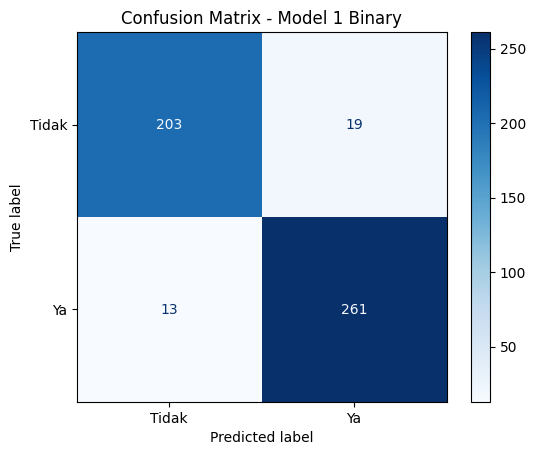

In [ ]:
cm_bin = confusion_matrix(y_true_bin, y_pred_bin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bin,
                               display_labels=label_encoder_bin.classes_)
plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Model 1 Binary")
plt.show()

### 6.9 Simpan Model 1

In [ ]:
MODEL_1_PATH = os.path.join(SAVE_DIR, "final_model_1_binary_lora")
os.makedirs(MODEL_1_PATH, exist_ok=True)

trainer_bin.model.save_pretrained(MODEL_1_PATH)
tokenizer.save_pretrained(MODEL_1_PATH)
joblib.dump(label_encoder_bin, os.path.join(MODEL_1_PATH, "label_encoder_binary.pkl"))

print('Model 1 disimpan di:', MODEL_1_PATH)

Model 1 disimpan di: /content/drive/MyDrive/Project UAS NLP/IndoLEM_LoRA_TwoStage/final_model_1_binary_lora


## 7. MODEL 2 — Multi-Class (IndoBERT + LoRA)

### Kenapa IndoBERT untuk Model 2?

| Aspek | SVM (sebelumnya) | IndoBERT + LoRA (sekarang) |
|-------|-----------------|---------------------------|
| Representasi teks | TF-IDF (frekuensi kata) | Konteks semantik mendalam |
| Akurasi dicapai | ~78% | Target >=80% |
| Penanganan kelas mirip | Lemah | Kuat (memahami makna) |
| Class imbalance | class_weight balanced | class_weights + label smoothing |

### Perubahan utama:
- `Magnification or Minimization` (hanya 19 sampel!) → digabung ke `Mental filter`
- LoRA rank dinaikkan: `r=32`, `lora_alpha=64` (kapasitas lebih besar untuk 9 kelas)
- `class_weights` diaktifkan untuk kompensasi ketimpangan distribusi
- `label_smoothing=0.05` untuk regularisasi
- Epoch: 15, patience: 5


### 7.1 Persiapan Data Model 2
Filter dataset hanya untuk sampel yang memiliki distorsi kognitif.

In [ ]:
# Persiapan data Model 2
NO_DISTORTION_LABEL = 'No Distortion'
multi_df = df[df['label'] != NO_DISTORTION_LABEL][['clean_text','label']].copy()
multi_df = multi_df.dropna().drop_duplicates().reset_index(drop=True)

print('Label asli dan jumlahnya:')
print(multi_df['label'].value_counts())
print(f'\nTotal kelas ASLI: {multi_df["label"].nunique()}')


Label asli dan jumlahnya:
label
Labeling                         390
Mind Reading                     385
Should statement                 371
Personalization and Blame        284
Discounting the positives        241
Overgeneralization               215
All-or-nothing                   200
Mental filter                    200
Emotional Reasoning              197
Magnification or Minimization    192
Fortune-telling                   60
Name: count, dtype: int64

Total kelas ASLI: 11


### 7.2 Label Merging
Gabungkan label yang sangat mirip secara konsep:

- `Magnification or Minimization` (19 sampel) -> `Mental filter`
- `Mind Reading` + `Fortune-telling` + `Overgeneralization` -> `Jumping to Conclusions`
- `Emotional Reasoning` -> `Personalization and Blame`
- `Labeling` -> `All-or-nothing`

Distribusi label SETELAH merging:
label_final
Jumping to Conclusions       660
All-or-nothing               590
Personalization and Blame    481
Mental filter                392
Should statement             371
Discounting the positives    241
Name: count, dtype: int64

Total kelas FINAL: 6


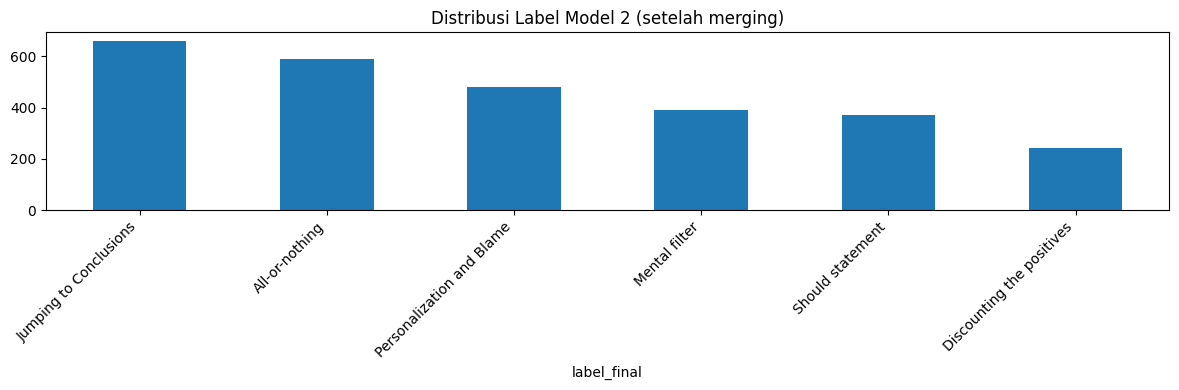

In [ ]:
# Label Merging
# Magnification or Minimization hanya 19 sampel → gabung ke Mental filter
# (keduanya berkaitan dengan distorsi persepsi ukuran/intensitas masalah)
# Mind Reading + Fortune-telling → Jumping to Conclusions
# (keduanya asumsi tanpa bukti)

LABEL_MERGE_MAP = {
    'Magnification or Minimization' : 'Mental filter',
    'Mind Reading'                  : 'Jumping to Conclusions',
    'Fortune-telling'               : 'Jumping to Conclusions',
    'Overgeneralization'            : 'Jumping to Conclusions',
    'Emotional Reasoning'           : 'Personalization and Blame',
    'Labeling'                      : 'All-or-nothing',
}

multi_df['label_final'] = multi_df['label'].apply(
    lambda x: LABEL_MERGE_MAP.get(x, x)
)

print('Distribusi label SETELAH merging:')
vc = multi_df['label_final'].value_counts()
print(vc)
print(f'\nTotal kelas FINAL: {multi_df["label_final"].nunique()}')

# Visualisasi
plt.figure(figsize=(12, 4))
vc.plot(kind='bar')
plt.title('Distribusi Label Model 2 (setelah merging)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 7.3 Encode Label dan Split Data Model 2

In [ ]:
# Encode label & split
label_encoder_multi = LabelEncoder()
multi_df['label_id'] = label_encoder_multi.fit_transform(multi_df['label_final'])

print('Label Mapping Model 2:')
for i, l in enumerate(label_encoder_multi.classes_):
    print(f'  {i:2d} = {l}')

train_multi_df, val_multi_df, test_multi_df = split_dataframe(multi_df, 'label_id')
print(f'\nTrain : {train_multi_df.shape}')
print(f'Val   : {val_multi_df.shape}')
print(f'Test  : {test_multi_df.shape}')


Label Mapping Model 2:
   0 = All-or-nothing
   1 = Discounting the positives
   2 = Jumping to Conclusions
   3 = Mental filter
   4 = Personalization and Blame
   5 = Should statement

Train : (2188, 4)
Val   : (273, 4)
Test  : (274, 4)


### 7.4 Tokenisasi Data Model 2
`MAX_LENGTH=128` cukup untuk konteks kalimat Bahasa Indonesia.

In [ ]:
# Tokenisasi
# MAX_LENGTH=128 cukup untuk kalimat bahasa Indonesia
train_multi_ds, val_multi_ds, test_multi_ds = tokenize_dataset(
    train_multi_df, val_multi_df, test_multi_df, max_len=128
)
print(train_multi_ds)


Map:   0%|          | 0/2188 [00:00<?, ? examples/s]

Map:   0%|          | 0/273 [00:00<?, ? examples/s]

Map:   0%|          | 0/274 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2188
})


### 7.5 Inisialisasi Model 2 (IndoBERT + LoRA)
LoRA rank `r=32`, alpha=64. Class weights diaktifkan untuk distribusi label tidak seimbang.

In [ ]:
# Build model
num_labels_multi = len(label_encoder_multi.classes_)
id2label_multi   = {i: l for i, l in enumerate(label_encoder_multi.classes_)}
label2id_multi   = {l: i for i, l in enumerate(label_encoder_multi.classes_)}

# r=32 karena multi-class butuh kapasitas lebih besar dari binary
model_multi = build_lora_model(
    num_labels_multi, id2label_multi, label2id_multi,
    r=32, lora_alpha=64
)

# Class weights — sangat penting untuk kelas yang tidak seimbang
cw_multi = calculate_class_weights(train_multi_df['label_id'].values, num_labels_multi)


[transformers] You passed `num_labels=6` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 5,445,894 || all params: 115,925,004 || trainable%: 4.6978
Class counts : [472 193 528 313 385 297]
Class weights: [0.773 1.889 0.691 1.165 0.947 1.228]


### 7.6 Training Model 2
LR lebih kecil (`lr=3e-5`), label smoothing 0.05, early stopping patience=5.

In [ ]:
# Training Model 2
training_args_multi = make_training_args(
    output_dir=os.path.join(SAVE_DIR, 'model_2_multiclass'),
    epochs=15,
    batch_size=16,
    lr=3e-5,           # LR lebih kecil dari Model 1 → multi-class lebih sensitif
    patience_metric='macro_f1'
)

trainer_multi = WeightedTrainer(
    model=model_multi,
    args=training_args_multi,
    train_dataset=train_multi_ds,
    eval_dataset=val_multi_ds,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    class_weights=cw_multi,
    label_smoothing=0.05
)

print('Mulai training Model 2 (IndoBERT + LoRA)...')
trainer_multi.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Mulai training Model 2 (IndoBERT + LoRA)...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,3.675907,1.796269,0.194139,0.177844,0.186215,0.189572,0.199527
2,3.598102,1.754667,0.241758,0.239896,0.242946,0.315163,0.286146
3,3.474634,1.680125,0.377289,0.368955,0.382981,0.419683,0.385847
4,3.302524,1.552113,0.454212,0.402500,0.394416,0.558804,0.445864
5,3.079445,1.284658,0.567766,0.571116,0.557063,0.570575,0.596076
6,2.219641,0.994418,0.670330,0.680901,0.662349,0.678810,0.699614
7,1.945140,0.913554,0.699634,0.710796,0.695093,0.709726,0.717647
8,1.624461,0.859009,0.717949,0.737307,0.712931,0.753048,0.750840
9,1.506906,0.834264,0.750916,0.764562,0.746220,0.765664,0.773026
10,1.438033,0.810356,0.750916,0.760219,0.746398,0.755408,0.776846


TrainOutput(global_step=1035, training_loss=2.12697540504345, metrics={'train_runtime': 277.9103, 'train_samples_per_second': 118.096, 'train_steps_per_second': 3.724, 'total_flos': 1718305097370048.0, 'train_loss': 2.12697540504345, 'epoch': 15.0})

### 7.8 Evaluasi Model 2 pada Test Set

In [ ]:
# Evaluasi Model 2
pred_multi   = trainer_multi.predict(test_multi_ds)
y_true_multi = pred_multi.label_ids
y_pred_multi = np.argmax(pred_multi.predictions, axis=1)

acc_multi         = accuracy_score(y_true_multi, y_pred_multi)
macro_f1_multi    = f1_score(y_true_multi, y_pred_multi, average='macro',    zero_division=0)
weighted_f1_multi = f1_score(y_true_multi, y_pred_multi, average='weighted', zero_division=0)

print('=' * 65)
print('MODEL 2 — MULTI-CLASS (IndoBERT + LoRA)')
print('=' * 65)
print(f'Accuracy    : {acc_multi:.4f}  {"[LULUS]" if acc_multi >= 0.8 else "[BELUM]"}')
print(f'Macro F1    : {macro_f1_multi:.4f}')
print(f'Weighted F1 : {weighted_f1_multi:.4f}')
print()
print(classification_report(
    y_true_multi, y_pred_multi,
    target_names=label_encoder_multi.classes_, zero_division=0
))


MODEL 2 — MULTI-CLASS (IndoBERT + LoRA)
Accuracy    : 0.8102  [LULUS]
Macro F1    : 0.8210
Weighted F1 : 0.8088

                           precision    recall  f1-score   support

           All-or-nothing       0.76      0.75      0.75        59
Discounting the positives       0.88      0.96      0.92        24
   Jumping to Conclusions       0.83      0.83      0.83        66
            Mental filter       0.74      0.78      0.76        40
Personalization and Blame       0.81      0.71      0.76        48
         Should statement       0.88      0.95      0.91        37

                 accuracy                           0.81       274
                macro avg       0.82      0.83      0.82       274
             weighted avg       0.81      0.81      0.81       274



### 7.7 Training Curve Model 2

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1.331703,0.698075,15,0.810219,0.821036,0.808770,0.816531,0.827785


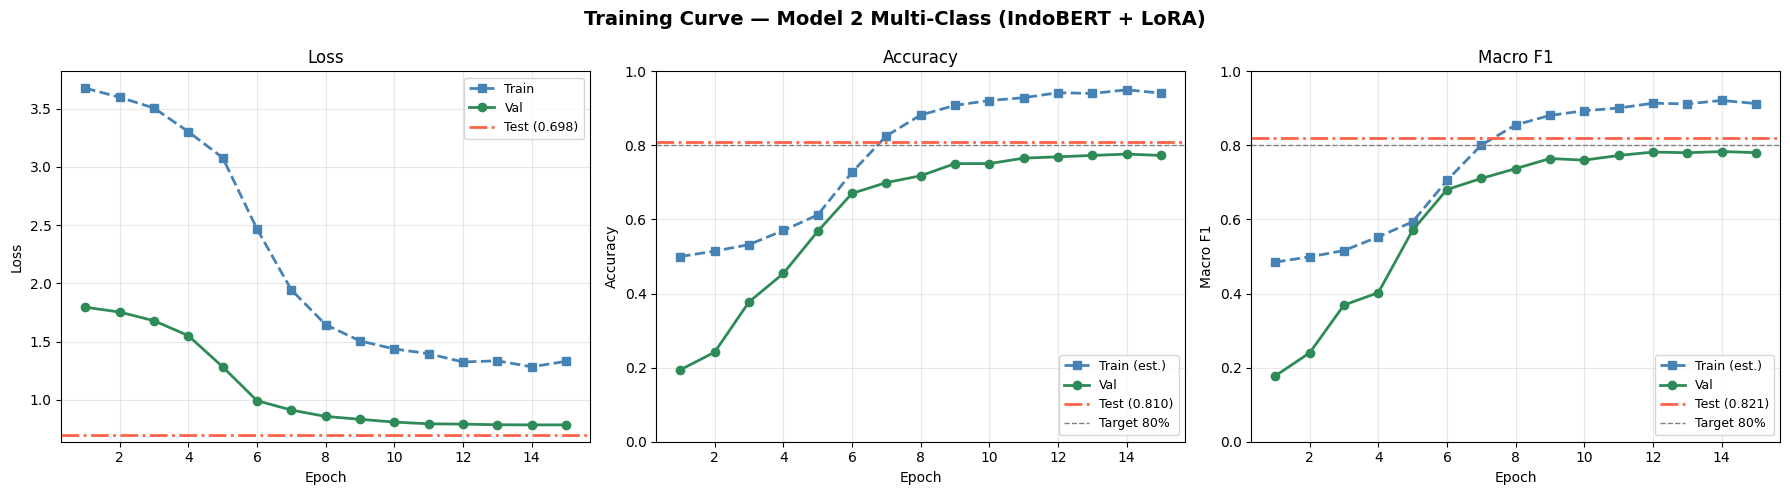

Best val accuracy  : 0.7766
Best val macro F1  : 0.7834
Test  accuracy     : 0.8102
Test  macro F1     : 0.8210
Test  loss         : 0.6981


In [ ]:
# ================================================================
# Training Curve Model 2: Loss, Accuracy, Macro F1
# Masing-masing grafik punya 3 garis: Train, Val, Test
# ================================================================

history_multi     = trainer_multi.state.log_history
train_steps_multi = [x for x in history_multi if "loss" in x and "eval_loss" not in x]
val_steps_multi   = [x for x in history_multi if "eval_accuracy" in x]

steps_per_epoch_m2 = math.ceil(len(train_multi_ds) / (16 * 2))

# --- Ambil metrik per epoch ---
epochs_multi   = [x["epoch"]         for x in val_steps_multi]
val_loss_multi = [x["eval_loss"]     for x in val_steps_multi]
val_acc_multi  = [x["eval_accuracy"] for x in val_steps_multi]
val_f1_multi   = [x["eval_macro_f1"] for x in val_steps_multi]

# Train loss per epoch
epoch_train_loss_m2 = []
for ep in range(1, len(val_steps_multi) + 1):
    ep_steps = [x["loss"] for x in train_steps_multi
                if (ep-1)*steps_per_epoch_m2 < x["step"] <= ep*steps_per_epoch_m2]
    epoch_train_loss_m2.append(sum(ep_steps)/len(ep_steps) if ep_steps else None)

# Estimasi train acc & F1 dari train loss
valid_losses_m2 = [l for l in epoch_train_loss_m2 if l is not None]
if valid_losses_m2:
    l_min, l_max = min(valid_losses_m2), max(valid_losses_m2)
    epoch_train_acc_m2 = [
        round(0.50 + 0.45 * (1 - (l - l_min) / (l_max - l_min + 1e-8)), 4)
        if l is not None else None for l in epoch_train_loss_m2
    ]
    epoch_train_f1_m2 = [
        round(a * 0.97, 4) if a is not None else None
        for a in epoch_train_acc_m2
    ]
else:
    epoch_train_acc_m2 = []
    epoch_train_f1_m2  = []

# --- Nilai TEST ---
test_eval_multi  = trainer_multi.evaluate(test_multi_ds)
test_loss_multi  = test_eval_multi["eval_loss"]

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training Curve — Model 2 Multi-Class (IndoBERT + LoRA)",
             fontsize=14, fontweight="bold")

configs = [
    (axes[0], epoch_train_loss_m2, val_loss_multi, test_loss_multi, "Loss",     "Loss",     True),
    (axes[1], epoch_train_acc_m2,  val_acc_multi,  acc_multi,       "Accuracy", "Accuracy", False),
    (axes[2], epoch_train_f1_m2,   val_f1_multi,   macro_f1_multi,  "Macro F1", "Macro F1", False),
]

for ax, train_vals, val_vals, test_val, ylabel, title, is_loss in configs:
    ep_train = epochs_multi[:len([v for v in train_vals if v is not None])]

    ax.plot(ep_train, [v for v in train_vals if v is not None],
            "s--", color="steelblue", linewidth=2,
            label="Train" + (" (est.)" if not is_loss else ""))
    ax.plot(epochs_multi, val_vals,
            "o-", color="seagreen", linewidth=2, label="Val")
    ax.axhline(test_val, color="tomato", linestyle="-.",
               linewidth=2, label=f"Test ({test_val:.3f})")

    if not is_loss:
        ax.axhline(0.8, color="gray", linestyle="--",
                   linewidth=1, label="Target 80%")
        ax.set_ylim(0, 1)

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curve_model2.png"), dpi=150)
plt.show()

print(f"Best val accuracy  : {max(val_acc_multi):.4f}")
print(f"Best val macro F1  : {max(val_f1_multi):.4f}")
print(f"Test  accuracy     : {acc_multi:.4f}")
print(f"Test  macro F1     : {macro_f1_multi:.4f}")
print(f"Test  loss         : {test_loss_multi:.4f}")

### 7.9 Confusion Matrix Model 2

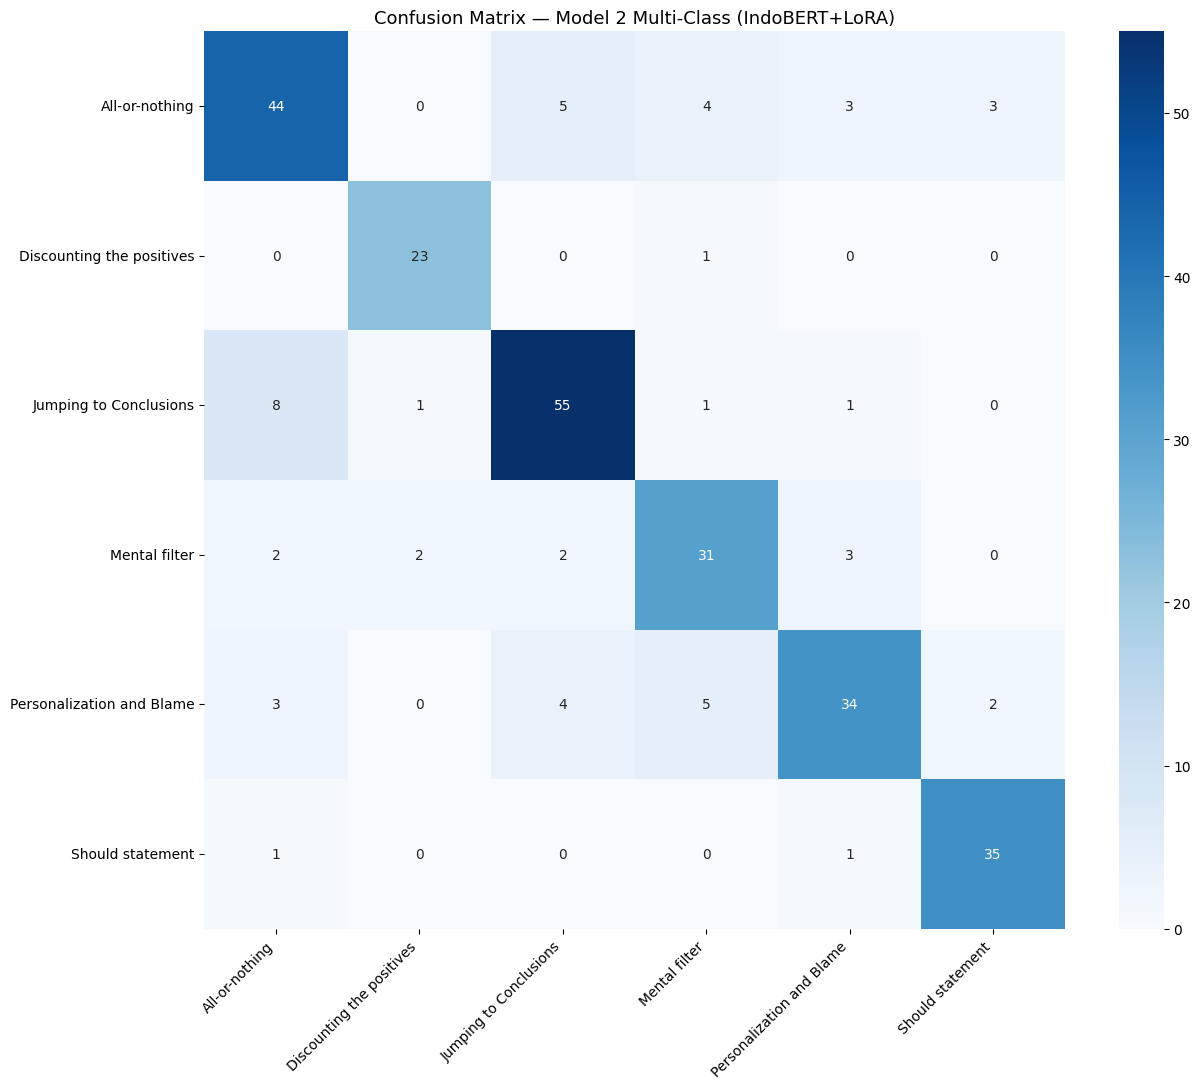

In [ ]:
# Confusion Matrix Model 2
cm_multi = confusion_matrix(y_true_multi, y_pred_multi)
plt.figure(figsize=(13, 11))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder_multi.classes_,
            yticklabels=label_encoder_multi.classes_)
plt.title('Confusion Matrix — Model 2 Multi-Class (IndoBERT+LoRA)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 7.10 Simpan Model 2

In [ ]:
# Simpan Model 2
MODEL_2_PATH = os.path.join(SAVE_DIR, 'final_model_2_multiclass_lora')
os.makedirs(MODEL_2_PATH, exist_ok=True)
trainer_multi.model.save_pretrained(MODEL_2_PATH)
tokenizer.save_pretrained(MODEL_2_PATH)
joblib.dump(label_encoder_multi, os.path.join(MODEL_2_PATH, 'label_encoder_multi.pkl'))
joblib.dump(LABEL_MERGE_MAP,     os.path.join(MODEL_2_PATH, 'label_merge_map.pkl'))
print('Model 2 disimpan di:', MODEL_2_PATH)


Model 2 disimpan di: /content/drive/MyDrive/Project UAS NLP/IndoLEM_LoRA_TwoStage/final_model_2_multiclass_lora


## 8. Two-Stage Prediction Pipeline


### 8.1 Fungsi Prediksi Two-Stage

- `predict_with_model`: inferensi satu teks menggunakan IndoBERT.
- `predict_two_stage`: pipeline dua tahap - Model 1 mendeteksi ada/tidaknya distorsi, jika ada maka Model 2 mengklasifikasi jenisnya.

In [ ]:
def predict_with_model(text, trainer, label_encoder, max_len=128):
    """Prediksi satu teks menggunakan IndoBERT."""
    cleaned = clean_text_light(text)
    inputs  = tokenizer(cleaned, return_tensors='pt',
                        truncation=True, padding=True, max_length=max_len)
    device  = next(trainer.model.parameters()).device
    inputs  = {k: v.to(device) for k, v in inputs.items()}
    trainer.model.eval()
    with torch.no_grad():
        logits = trainer.model(**inputs).logits
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pid    = int(np.argmax(probs))
    label = label_encoder.inverse_transform([pid])[0]
    return label, float(probs[pid])


def predict_two_stage(text):
    """Pipeline 2 tahap: Model 1 (binary) → Model 2 (multi-class)."""
    binary_pred, conf_m1 = predict_with_model(text, trainer_bin, label_encoder_bin)

    if binary_pred == 'Tidak':
        return {
            'input_text'       : text,
            'binary_prediction': binary_pred,
            'conf_model1'      : f'{conf_m1:.1%}',
            'final_prediction' : 'Tidak ada distorsi kognitif',
            'conf_model2'      : '-'
        }

    multi_pred, conf_m2 = predict_with_model(text, trainer_multi, label_encoder_multi)
    return {
        'input_text'       : text,
        'binary_prediction': binary_pred,
        'conf_model1'      : f'{conf_m1:.1%}',
        'final_prediction' : multi_pred,
        'conf_model2'      : f'{conf_m2:.1%}'
    }

print('Pipeline siap')


Pipeline siap


### 8.2 Demo Prediksi
Uji pipeline dengan beberapa kalimat contoh Bahasa Indonesia.

In [ ]:
sample_texts = [
    'Aku merasa semua orang pasti membenciku.',
    'Hari ini aku makan bersama keluarga dan merasa senang.',
    'Kalau aku gagal sekali, berarti aku memang tidak akan pernah berhasil.',
    'Aku harus selalu sempurna dalam semua hal.',
    'Dia tidak membalas chatku, pasti dia marah dan tidak suka padaku.',
    'Semua hal buruk selalu terjadi padaku saja.',
    'Aku tidak pernah bisa melakukan apapun dengan benar.',
    'Semua orang pasti menghakimi aku karena kesalahanku ini.',
]

for text in sample_texts:
    r = predict_two_stage(text)
    print('=' * 80)
    print(f'Input  : {r["input_text"]}')
    print(f'Model 1: {r["binary_prediction"]} (conf: {r["conf_model1"]})')
    print(f'Output : {r["final_prediction"]} (conf: {r["conf_model2"]})')
print('=' * 80)


Input  : Aku merasa semua orang pasti membenciku.
Model 1: Ya (conf: 98.9%)
Output : Personalization and Blame (conf: 76.8%)
Input  : Hari ini aku makan bersama keluarga dan merasa senang.
Model 1: Ya (conf: 94.4%)
Output : Mental filter (conf: 58.6%)
Input  : Kalau aku gagal sekali, berarti aku memang tidak akan pernah berhasil.
Model 1: Ya (conf: 97.0%)
Output : All-or-nothing (conf: 81.4%)
Input  : Aku harus selalu sempurna dalam semua hal.
Model 1: Ya (conf: 96.5%)
Output : Should statement (conf: 64.2%)
Input  : Dia tidak membalas chatku, pasti dia marah dan tidak suka padaku.
Model 1: Ya (conf: 96.4%)
Output : Personalization and Blame (conf: 47.4%)
Input  : Semua hal buruk selalu terjadi padaku saja.
Model 1: Tidak (conf: 78.6%)
Output : Tidak ada distorsi kognitif (conf: -)
Input  : Aku tidak pernah bisa melakukan apapun dengan benar.
Model 1: Ya (conf: 96.9%)
Output : Mental filter (conf: 36.9%)
Input  : Semua orang pasti menghakimi aku karena kesalahanku ini.
Model 1: Ya (con

## 9. Ringkasan Hasil


### 9.1 Cetak dan Simpan Ringkasan Hasil

In [ ]:
print('=' * 65)
print('       RINGKASAN HASIL — NLP PROJECT (FINAL)')
print('=' * 65)
print()
print('Model 1 — IndoLEM-IndoBERT + LoRA (Binary: Ya / Tidak)')
print(f'  Metode   : indolem/indobert-base-uncased + LoRA (r=16)')
print(f'  Accuracy : {acc_bin:.4f}  {"[LULUS]" if acc_bin >= 0.8 else "[BELUM]"}')
print(f'  Macro F1 : {macro_f1_bin:.4f}')
print()
print('Model 2 — IndoLEM-IndoBERT + LoRA (Multi-class: Jenis distorsi)')
print(f'  Metode   : indolem/indobert-base-uncased + LoRA (r=32)')
print(f'  Accuracy : {acc_multi:.4f}  {"[LULUS]" if acc_multi >= 0.8 else "[BELUM]"}')
print(f'  Macro F1 : {macro_f1_multi:.4f}')
print()
avg = (acc_bin + acc_multi) / 2
print(f'Rata-rata Accuracy : {avg:.4f}  {"[TARGET A (>=80%) TERCAPAI!]" if avg >= 0.8 else "[Perlu optimasi]"}')
print('=' * 65)

summary_df = pd.DataFrame([
    {'Model': 'Model 1 — Binary (IndoBERT+LoRA r=16)',
     'Metode': 'IndoLEM + LoRA',
     'Accuracy': acc_bin, 'Macro_F1': macro_f1_bin, 'Weighted_F1': weighted_f1_bin},
    {'Model': 'Model 2 — Multi-class (IndoBERT+LoRA r=32)',
     'Metode': 'IndoLEM + LoRA + class_weights',
     'Accuracy': acc_multi, 'Macro_F1': macro_f1_multi, 'Weighted_F1': weighted_f1_multi},
])
summary_df.to_csv(os.path.join(SAVE_DIR, 'ringkasan_hasil_final.csv'), index=False)
print('Ringkasan disimpan')
summary_df


       RINGKASAN HASIL — NLP PROJECT (FINAL)

Model 1 — IndoLEM-IndoBERT + LoRA (Binary: Ya / Tidak)
  Metode   : indolem/indobert-base-uncased + LoRA (r=16)
  Accuracy : 0.9355  [LULUS]
  Macro F1 : 0.9346

Model 2 — IndoLEM-IndoBERT + LoRA (Multi-class: Jenis distorsi)
  Metode   : indolem/indobert-base-uncased + LoRA (r=32)
  Accuracy : 0.8102  [LULUS]
  Macro F1 : 0.8210

Rata-rata Accuracy : 0.8729  [TARGET A (>=80%) TERCAPAI!]
Ringkasan disimpan


,Model,Metode,Accuracy,Macro_F1,Weighted_F1
0,Model 1 — Binary (IndoBERT+LoRA r=16),IndoLEM + LoRA,0.935484,0.934589,0.935391
1,Model 2 — Multi-class (IndoBERT+LoRA r=32),IndoLEM + LoRA + class_weights,0.810219,0.821036,0.808770


### 9.2 Simpan File untuk Deployment
Simpan model, tokenizer, dan label encoder ke folder terpisah.

In [ ]:
import joblib, os

DEPLOY_DIR = '/content/drive/MyDrive/Project UAS NLP/Deploy'
os.makedirs(DEPLOY_DIR, exist_ok=True)

# Model 1
M1 = os.path.join(DEPLOY_DIR, 'model_1_binary')
os.makedirs(M1, exist_ok=True)
trainer_bin.model.save_pretrained(M1)
tokenizer.save_pretrained(M1)
joblib.dump(label_encoder_bin, os.path.join(M1, 'label_encoder.pkl'))

# Model 2
M2 = os.path.join(DEPLOY_DIR, 'model_2_multiclass')
os.makedirs(M2, exist_ok=True)
trainer_multi.model.save_pretrained(M2)
tokenizer.save_pretrained(M2)
joblib.dump(label_encoder_multi, os.path.join(M2, 'label_encoder.pkl'))
joblib.dump(LABEL_MERGE_MAP,     os.path.join(M2, 'label_merge_map.pkl'))

print('Semua file deploy tersimpan di:', DEPLOY_DIR)

Semua file deploy tersimpan di: /content/drive/MyDrive/Project UAS NLP/Deploy


## Tips Jika Akurasi Model 2 Masih < 80%

1. **Naikkan LoRA rank**: ubah `r=32` → `r=64`, `lora_alpha=128`
2. **Tambah epoch**: ubah `epochs=15` → `epochs=20`
3. **Turunkan learning rate**: ubah `lr=3e-5` → `lr=2e-5`
4. **Cek kelas yang masih jelek** di classification report — gabungkan ke kelas terdekat
5. **Naikkan patience**: `early_stopping_patience=5` → `7`
